# Vision2Text: AI Powered Image Caption Generator using DL

## Import Required Libraries :

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import random
import pickle
import warnings
warnings.filterwarnings('ignore')

from PIL import Image

!pip install kaggle --quiet
!pip install tensorflow --quiet
!pip install nltk --quiet

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array

from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical

from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, add

from tensorflow.keras.preprocessing.sequence import pad_sequences

from nltk.translate.bleu_score import corpus_bleu

## Data Acquisition & Loading :

In [ ]:
!kaggle datasets download -d adityajn105/flickr8k

Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k
License(s): CC0-1.0
100% 1.04G/1.04G [00:23<00:00, 46.6MB/s]



In [ ]:
# check the dataset zip file exists
import os
os.listdir()

['.config', 'flickr8k.zip', 'sample_data']

In [ ]:
# unzip the dataset
import zipfile

with zipfile.ZipFile("flickr8k.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [ ]:
# verify extraction
os.listdir("data")

['captions.txt', 'Images']

In [ ]:
# check images and text folder
import os

# Count the number of image files in the 'Images' directory
print(len(os.listdir("/content/data/Images")))

# Open the captions.txt file and count the number of lines
with open("/content/data/captions.txt", 'r') as f:
    lines = f.readlines()
print(len(lines))

8091
40456


In [ ]:
# loading captions file
captions_df = pd.read_csv("/content/data/captions.txt")
captions_df.head()

,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


## Caption Parsing & Structuring :

In [ ]:
# Read the raw content of captions.txt into the 'text' variable
with open("/content/data/captions.txt", 'r') as f:
    text = f.read()

def parse_captions(text):
    captions = {}
    lines = text.split('\n')

    # Skip the header line 'image,caption'
    for line in lines[1:]:   # loop through each line starting from the second one
        if len(line) < 2:   # skip empty lines
            continue

        parts = line.split(',')   # split line by comma
        if len(parts) < 2:   # safety check
            continue

        image_id = parts[0]   # extract image id (no '#0' to split)
        caption = parts[1]   # extract caption

        if image_id not in captions:   # create entry if not exists
            captions[image_id] = []

        captions[image_id].append(caption)   # append caption

    return captions

captions = parse_captions(text)

In [ ]:
print("Total Images:", len(captions))

key = list(captions.keys())[0]
print(captions[key])

Total Images: 8091
['A child in a pink dress is climbing up a set of stairs in an entry way .', 'A girl going into a wooden building .', 'A little girl climbing into a wooden playhouse .', 'A little girl climbing the stairs to her playhouse .', 'A little girl in a pink dress going into a wooden cabin .']


## Exploratory Data Analysis (EDA) :

In [ ]:
# total images
print("Total images:", len(captions))

Total images: 8091


In [ ]:
# captions per image
print(set(len(v) for v in captions.values()))

{5}


In [ ]:
# total captions
total_captions = sum(len(v) for v in captions.values())
print("Total Captions:", total_captions)

Total Captions: 40455


In [ ]:
# captions length analysis
all_captions = []
for caps in captions.values():
  all_captions.extend(caps)

caption_lengths = [len(cap.split()) for cap in all_captions]

print("Min length:", min(caption_lengths))
print("Max length:", max(caption_lengths))
print("Avg Length:", sum(caption_lengths) / len(caption_lengths))

Min length: 1
Max length: 34
Avg Length: 11.210950438759115


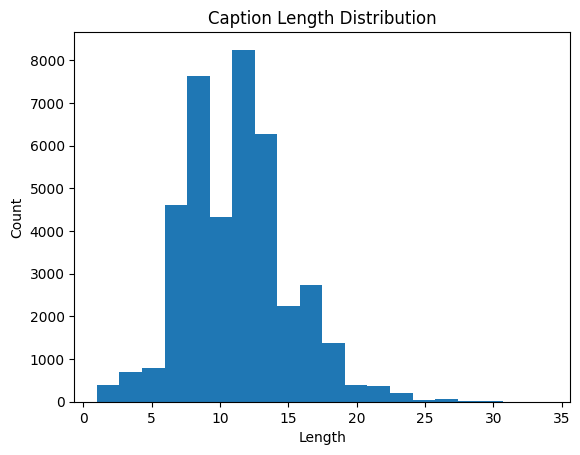

In [ ]:
# plot distribution
plt.hist(caption_lengths, bins=20)
plt.title("Caption Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()

In [ ]:
# most common words
from collections import Counter

words = []
for cap in all_captions:
  words.extend(cap.split())

word_counts = Counter(words)
print(word_counts.most_common(10))

[('a', 38716), ('.', 34205), ('A', 21480), ('in', 18170), ('the', 14587), ('on', 10354), ('is', 9069), ('and', 8057), ('dog', 7804), ('with', 7303)]


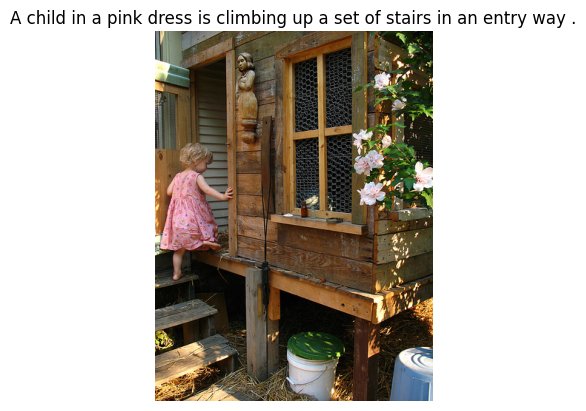

In [ ]:
# visual check (image + caption)
from PIL import Image
import matplotlib.pyplot as plt

img_name = list(captions.keys())[0]
img_path = "/content/data/Images/" + img_name # Added a forward slash here

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.title(captions[img_name][0])
plt.show()

## Text Preprocessing (Caption Cleaning) :

In [ ]:
import string

def clean_captions(captions):
    table = str.maketrans('', '', string.punctuation)

    for key, cap_list in captions.items():
        for i in range(len(cap_list)):
            caption = cap_list[i]

            # lowercase
            caption = caption.lower()

            # remove punctuation
            caption = caption.translate(table)

            # split words
            caption = caption.split()

            # remove short/invalid words
            caption = [word for word in caption if len(word) > 1 and word.isalpha()]

            # add tokens
            caption = ['startseq'] + caption + ['endseq']

            cap_list[i] = ' '.join(caption)

clean_captions(captions)

In [ ]:
key = list(captions.keys())[0]
print(captions[key])

['startseq child in pink dress is climbing up set of stairs in an entry way endseq', 'startseq girl going into wooden building endseq', 'startseq little girl climbing into wooden playhouse endseq', 'startseq little girl climbing the stairs to her playhouse endseq', 'startseq little girl in pink dress going into wooden cabin endseq']


## Text Encoding & Tokenization :



In [ ]:
# create vocabulary
all_captions = []
for caps in captions.values():
  all_captions.extend(caps)

tokenizer = Tokenizer()   # fit tokenizer
tokenizer.fit_on_texts(all_captions)

vocab_size = len(tokenizer.word_index) + 1   # vocabulary size
print("Vocab size:", vocab_size)

Vocab size: 8574


In [ ]:
# convert text to sequences
sequences = tokenizer.texts_to_sequences(all_captions)

print(all_captions[0])
print(sequences[0])

startseq child in pink dress is climbing up set of stairs in an entry way endseq
[1, 42, 3, 87, 168, 6, 114, 51, 389, 11, 381, 3, 27, 5051, 686, 2]


In [ ]:
# max caption length
max_length = max(len(seq) for seq in sequences)
print("Max length:", max_length)

Max length: 31


## Image Feature Extraction using CNN (VGG16) :

In [ ]:
# load pretrained CNN model
model = VGG16()

# remove last layer (classification layes)
model = Model(inputs=model.inputs, outputs=model.layers[-2].output)

In [ ]:
def extract_features(directory, batch_size=32):
    features = {}

    img_names = os.listdir(directory)

    for i in range(0, len(img_names), batch_size):
        batch = img_names[i:i+batch_size]

        images = []
        names = []

        for img_name in batch:
            img_path = os.path.join(directory, img_name)

            image = load_img(img_path, target_size=(224, 224))
            image = img_to_array(image)

            images.append(image)
            names.append(img_name)

        images = np.array(images)
        images = preprocess_input(images)

        batch_features = model.predict(images, verbose=0)

        for j, name in enumerate(names):
            features[name] = batch_features[j]

    return features

In [ ]:
# run feature extraction
features = extract_features("/content/data/Images")

In [ ]:
print(len(features))  # ~8000

key = list(features.keys())[0]
print(features[key].shape)

8091
(4096,)


In [ ]:
# save features
with open("features.pkl", "wb") as f:
    pickle.dump(features, f)

## Sequence Preparation using Data Generator :

In [ ]:
# use generator to avoid system run-time crash
def data_generator(captions, features, tokenizer, max_length, vocab_size, batch_size=32):

    X1, X2, y = [], [], []

    while True:
        for image_id, cap_list in captions.items():

            for caption in cap_list:

                seq = tokenizer.texts_to_sequences([caption])[0]

                for i in range(1, len(seq)):

                    in_seq = seq[:i]
                    out_seq = seq[i]

                    in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
                    out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]

                    X1.append(features[image_id])
                    X2.append(in_seq)
                    y.append(out_seq)

                    if len(X1) == batch_size:
                        yield (np.array(X1), np.array(X2)), np.array(y)
                        X1, X2, y = [], [], []

In [ ]:
# create generator
generator = data_generator(captions, features, tokenizer, max_length, vocab_size)

In [ ]:
# ModelCheckpoint
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='loss',
    save_best_only=True,
    verbose=1
)

# train model
model.fit(
    generator,
    epochs=epochs,
    steps_per_epoch=steps,
    callbacks=[checkpoint]
)

In [ ]:
# access one batch to see the shapes
(X1, X2), y = next(generator)

print("X1 shape:", X1.shape)
print("X2 shape:", X2.shape)
print("y shape:", y.shape)

X1 shape: (32, 4096)
X2 shape: (32, 31)
y shape: (32, 8574)


## Model Architecture (CNN + LSTM) :

In [ ]:
# define model
# Image feature input
inputs1 = Input(shape=(4096,))
fe1 = Dropout(0.5)(inputs1)
fe2 = Dense(512, activation='relu')(fe1)

# Text sequence input
inputs2 = Input(shape=(max_length,))
se1 = Embedding(vocab_size, 512)(inputs2)
se2 = Dropout(0.5)(se1)
se3 = LSTM(512)(se2)

# Combine both
decoder1 = add([fe2, se3])
decoder2 = Dense(256, activation='relu')(decoder1)

# Output layer
outputs = Dense(vocab_size, activation='softmax')(decoder2)

# Final model
model = Model(inputs=[inputs1, inputs2], outputs=outputs)

In [ ]:
# view summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 31)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 4096)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 31, 256)   │  2,194,944 │ input_layer_2[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 4096)      │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 31, 256)   │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,048,832 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 256)       │    525,312 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 256)       │          0 │ dense[0][0],      │
│                     │                   │            │ lstm[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8574)      │  2,203,518 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,038,400 (23.03 MB)

 Trainable params: 6,038,398 (23.03 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
# compile model
model.compile(loss='categorical_crossentropy', optimizer='adam')

## Model Training :

In [ ]:
# train model
epochs = 7
steps = len(captions)
generator = data_generator(captions, features, tokenizer, max_length, vocab_size)

model.fit(generator, epochs=epochs, steps_per_epoch=steps)

Epoch 1/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 93s 11ms/step - loss: 3.6971
Epoch 2/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 93s 12ms/step - loss: 3.6286
Epoch 3/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 97s 12ms/step - loss: 3.5826
Epoch 4/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 106s 13ms/step - loss: 3.5267
Epoch 5/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 107s 13ms/step - loss: 3.5039
Epoch 6/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 108s 13ms/step - loss: 3.4769
Epoch 7/7
8091/8091 ━━━━━━━━━━━━━━━━━━━━ 105s 13ms/step - loss: 3.4422


## Caption Generation :

In [ ]:
# function to map index -> word
def index_to_word(integer, tokenizer):
  for word, index in tokenizer.word_index.items():
    if index == integer:
      return word
  return None

In [ ]:
# caption generation
def generate_caption(photo, model, tokenizer, max_length, top_k=5):

    photo = photo.reshape((1, 4096))

    in_text = 'startseq'

    for i in range(max_length):

        sequence = tokenizer.texts_to_sequences([in_text])[0]
        sequence = pad_sequences([sequence], maxlen=max_length)

        yhat = model.predict([photo, sequence], verbose=0)

        yhat_probs = yhat[0]   # top-k sampling

        top_k = 3

        top_indices = np.argsort(yhat_probs)[-top_k:]
        yhat = np.random.choice(top_indices)

        word = index_to_word(yhat, tokenizer)

        if word is None:
            break

        in_text += ' ' + word

        if word == 'endseq':
            break

    return in_text

In [ ]:
# best model
model = load_model("best_model.h5")

In [ ]:
# generate caption
img_name = random.choice(list(captions.keys()))
photo = features[img_name]

caption = generate_caption(photo, model, tokenizer, max_length, top_k=2)

print("Raw:", caption)

Raw: startseq man wearing black and black jacket and blue shirt and red pants and blue pants is standing on the grass endseq


In [ ]:
# clean caption
def clean_output(caption):
    words = caption.split()
    return ' '.join(words[1:-1])   # removes startseq & endseq

print("Final:", clean_output(caption))

Final: man wearing black and black jacket and blue shirt and red pants and blue pants is standing on the grass


### Visualization (Image + Generated Caption) :

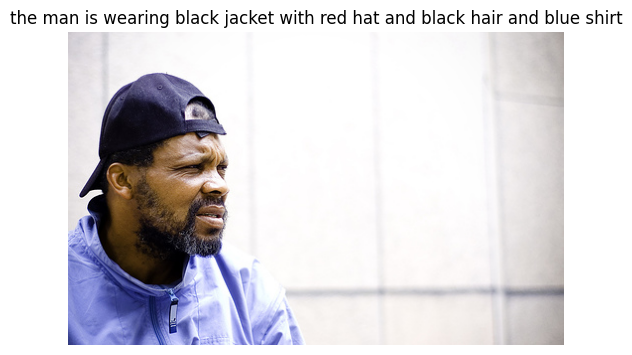

In [ ]:
# pick random image
img_name = random.choice(list(captions.keys()))
photo = features[img_name]

# generate caption
caption = generate_caption(photo, model, tokenizer, max_length, top_k=3)

# clean caption
def clean_output(caption):
    words = caption.split()
    return ' '.join(words[1:-1])

final_caption = clean_output(caption)

# load image
img_path = "/content/data/Images/" + img_name
img = Image.open(img_path)

# display
plt.imshow(img)
plt.axis('off')
plt.title(final_caption)
plt.show()

In [ ]:
print("Actual:", captions[img_name])
print("Predicted:", clean_output(caption))

Actual: ['startseq black man with facial hair wears navy hat and blue jacket in front of white background endseq', 'startseq man in blue cap and jacket looks frustrated endseq', 'startseq man wearing backwards baseball cap endseq', 'startseq man wearing blue baseball cap is gazing into the distance endseq', 'startseq man with beard and navy blue backwards baseball cap stares intently at something in the distance endseq']
Predicted: the man is wearing black jacket with red hat and black hair and blue shirt


## Model Evaluation using BLEU Score :

In [ ]:
actual, predicted = [], []   # prepare data

# loop through images
for img_name in list(captions.keys())[:50]:  # use subset for speed

    photo = features[img_name]

    y_pred = generate_caption(photo, model, tokenizer, max_length, top_k=3)
    y_pred = y_pred.split()[1:-1]  # remove start/end

    y_true = [cap.split() for cap in captions[img_name]]

    actual.append(y_true)
    predicted.append(y_pred)

In [ ]:
# calculate BLEU score
print("BLEU-1:", corpus_bleu(actual, predicted, weights=(1.0, 0, 0, 0)))
print("BLEU-2:", corpus_bleu(actual, predicted, weights=(0.5, 0.5, 0, 0)))

BLEU-1: 0.28846153846153844
BLEU-2: 0.1271513305385608


In [ ]:
# final model
model.save("final_model.h5")

In [ ]:
# save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [ ]:
# max length
with open("max_length.txt", "w") as f:
    f.write(str(max_length))